<a href="https://colab.research.google.com/github/tzmjoseph/UT_Austin_PGP_AIML_Projects/blob/main/ThomasJoseph_AIML_ML_Project_Full_Code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 106.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# Importing libraries and classes

# Libraries to read / manipulate data
import numpy as np
import pandas as pd

# Libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries to split data
import sklearn.model_selection as model_selection
from sklearn.model_selection import train_test_split

# Libraries / classes to build model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Classes to get various metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading the dataset
loan_modeling_data = pd.read_csv("/content/drive/MyDrive/Learning/UT Austin/02 - Machine Learning/Project/Loan_Modelling.csv")

In [ ]:
data = loan_modeling_data.copy()

## Data Overview

* Observations
* Sanity checks

### View the first and last 5 rows of the dataset.

In [ ]:
# Viewing the first 5 rows
data.head()

NameError: name 'data' is not defined

In [ ]:
# Viewing the last 5 rows
data.tail()

NameError: name 'data' is not defined

### Checking the shape of the dataset

In [ ]:
# Checking shape of data
data.shape

**Observations**


*   The dataset has 5000 records
*   Each row has 14 columns or data points



### Checking the data type of columns

In [ ]:
# Checking column data types
data.info()

**Observations**


*   All columns are numeric in nature with CCAvg being the only one with decimal values



### Checking for missing and duplicate values

In [ ]:
# Checking for missing values
data.isnull().sum()

NameError: name 'data' is not defined

In [ ]:
# Checking for duplicate values
data.duplicated().sum()

**Observations**


*   There are no null or duplicate values in the dataset



### Checking Statistical Summary

In [ ]:
# Getting statistical summary
data.describe().T

**Observations**


*   Experience has negative values that will need to be cleaned
*   Education will need to be changed to a category variable with one-hot encoding applied before it can be used in the data model



### Check column uniqueness

In [ ]:
# Checking if ID column is unique
data.ID.nunique()

**Observations**


*   ID has unique values so it can be dropped



### Dropping unique ID column

In [ ]:
# Drop the ID column
data.drop(columns=['ID'], inplace=True)

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

###Treating anomaly in Experience column

In [ ]:
# Checking unique values in Experience column
data.Experience.sort_values().unique()

array([-3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,
       14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
       31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43])

**Observations and Next Steps**


*   Negative values for Experience are an anomaly
*   Assuming that this was a data entry mistake and converting them to their absolute values



In [ ]:
# Changing negative values in the Experience column to their absolute values
data.Experience = data.Experience.abs()

###Feature Engineering - ZIP code

In [ ]:
# Converting ZIP Code column to string type
data['ZIPCode'] = data['ZIPCode'].astype(str)

In [ ]:
print("Two digit Zip Code Unique Count:", data['ZIPCode'].str[0:2].nunique())
print("Three digit Zip Code Unique Count:", data['ZIPCode'].str[0:3].nunique())


Two digit Zip Code Unique Count: 7
Three digit Zip Code Unique Count: 57


**Observations and Next Steps**


*   Converting to 2 digit zip codes will result in 7 unique values
*   Converting to 3 digit zip codes will result in 57 unique values
*   Will convert to 2 digit zip code as it would be easier for one-hot encoding



In [ ]:
data['ZIPCode'] = data['ZIPCode'].str[0:2]
data['ZIPCode'] = data['ZIPCode'].astype("category")

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

### Reusable Functions

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

###Univariate Analysis

####Age

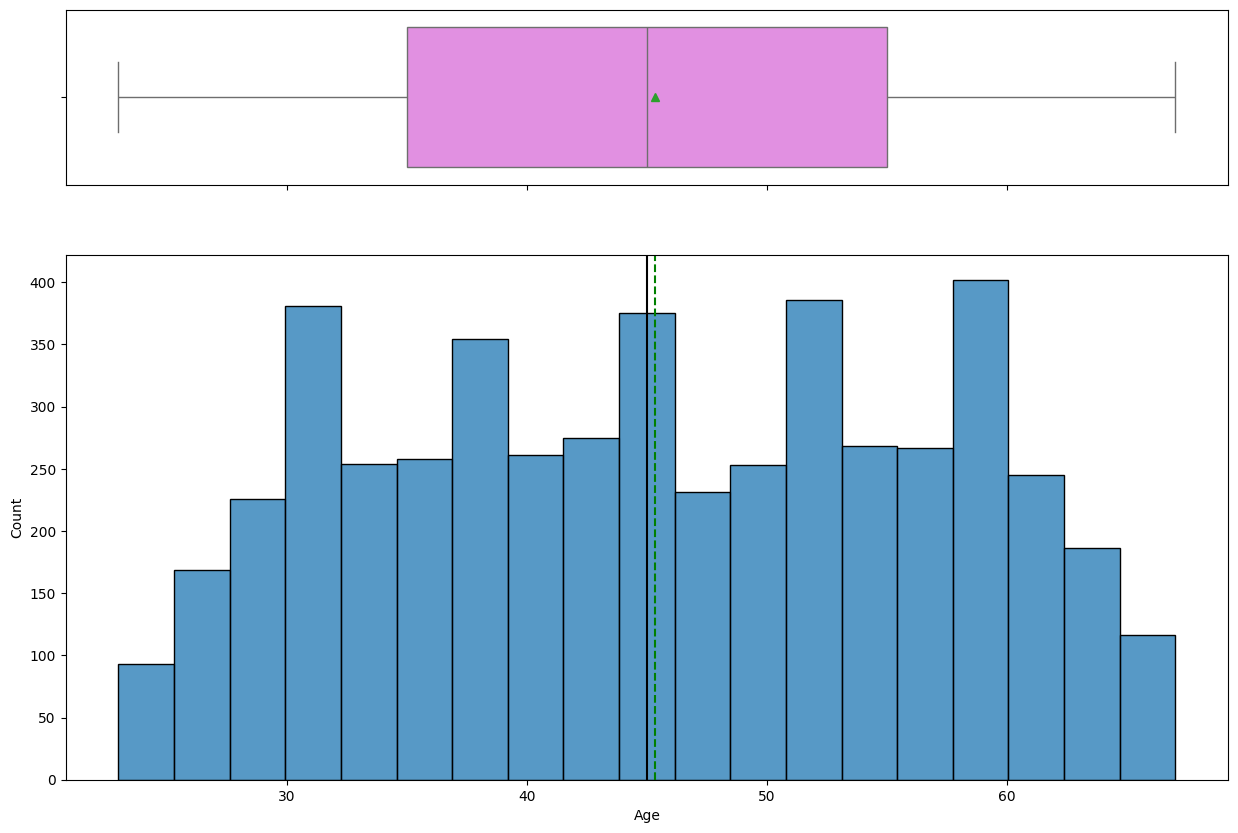

In [ ]:
# Creating histogram and boxplot for Age
histogram_boxplot(data, 'Age')

**Observations**


*   The data is close to normally distributed around the Age attribute
*   There is a very slight right skewness as can be seen by the fact that the Mean is slightly larger than the Median



####Experience

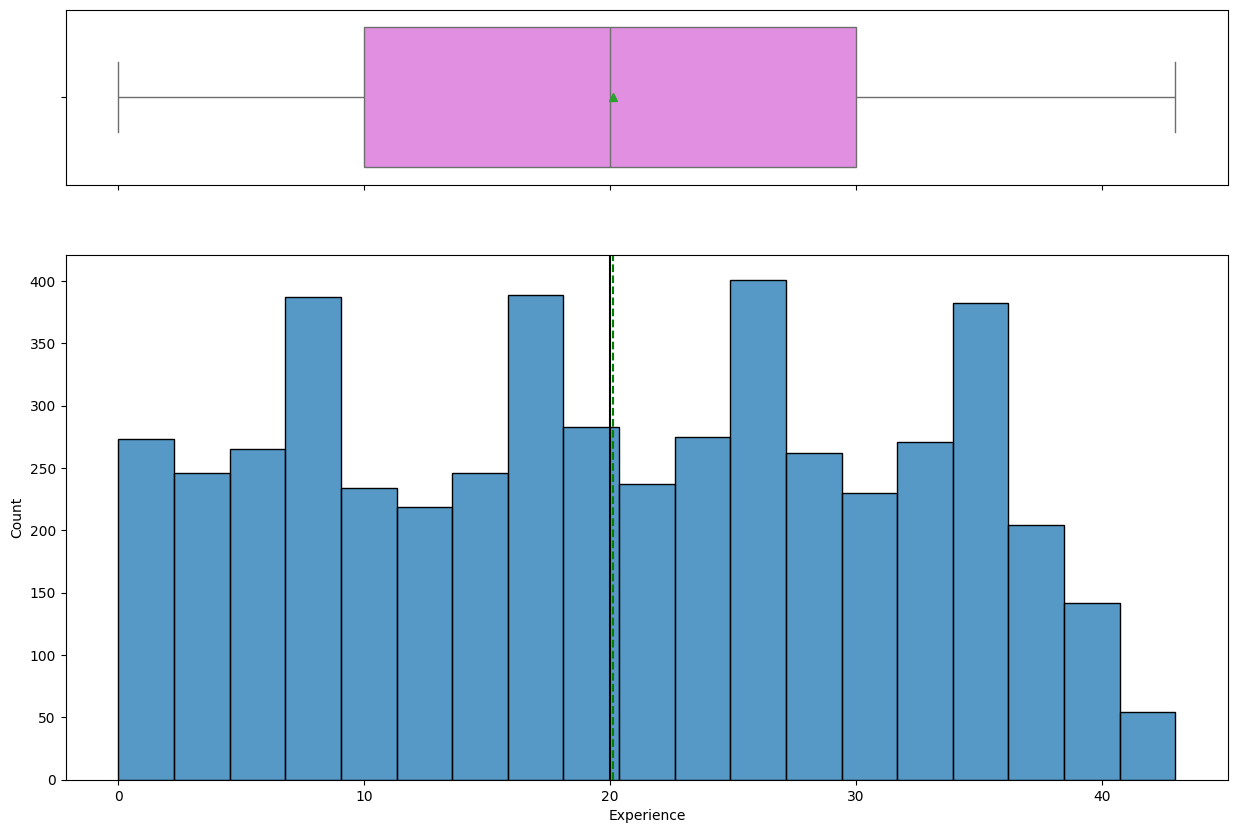

In [ ]:
# Creating histogram and boxplot for Experience
histogram_boxplot(data, 'Experience')

**Observations**


*   The data is normally distributed around the Experience attribute




#### Income

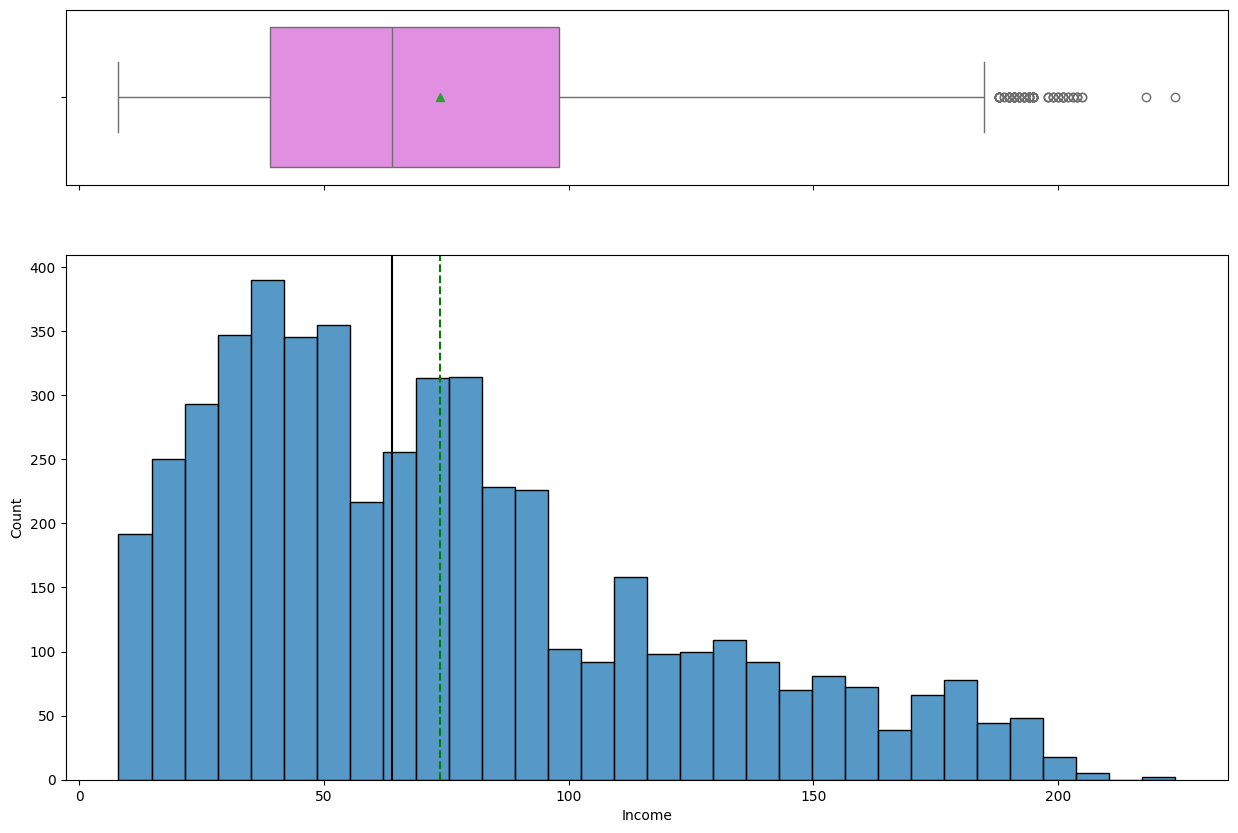

In [ ]:
# Creating histogram and boxplot for Income
histogram_boxplot(data, 'Income')

**Observations**


*   The data is right skewed when it comes to the Income attribute
*   There are outliers beyong the right whisker



#### Average Spending on Credit Cards

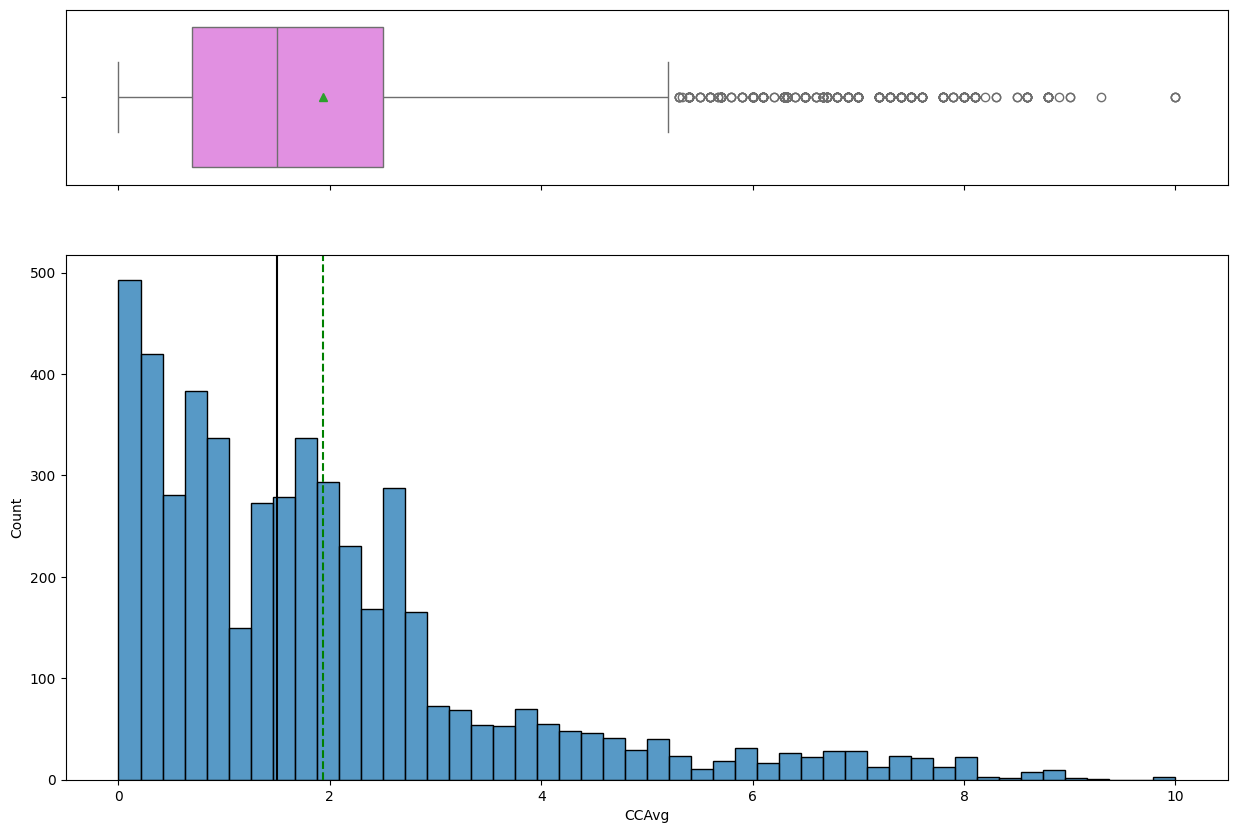

In [ ]:
# Creating histogram and boxplot for Average Spending on Credit Cards
histogram_boxplot(data, 'CCAvg')

**Observations**


*   The data is right skewed when it comes to the Average Spending on Credit Cards
*   There are outliers beyong the right whisker



#### Mortgage

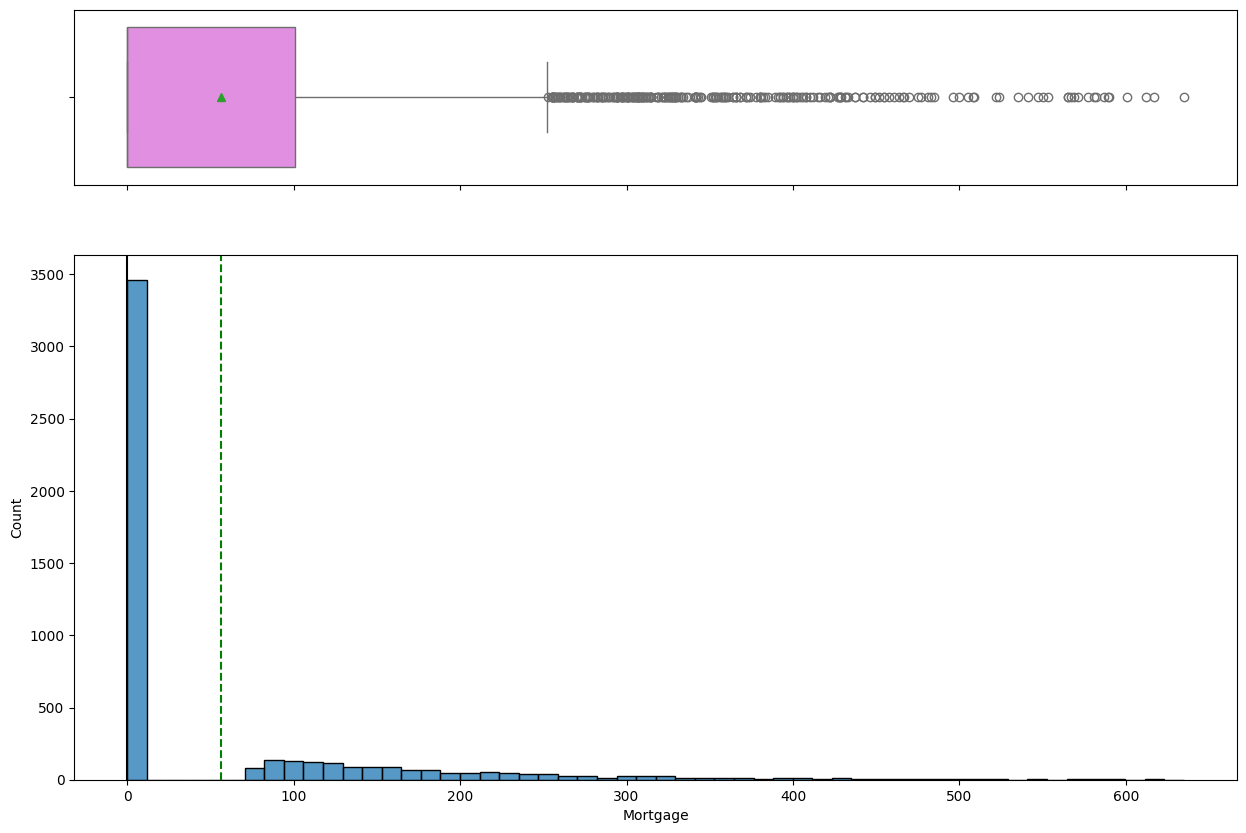

In [ ]:
# Creating histogram and boxplot for Mortgage
histogram_boxplot(data, 'Mortgage')

In [ ]:
data[data['Mortgage'] == 0].shape

(3462, 13)

**Observations**


*   The data is heavily skewed to the right when it comes to the Mortgage attribute
*   This is due to the fact that most customers (3462) do not have a mortgage (value = 0)
*   There are many outliers beyong the right whisker



#### Family

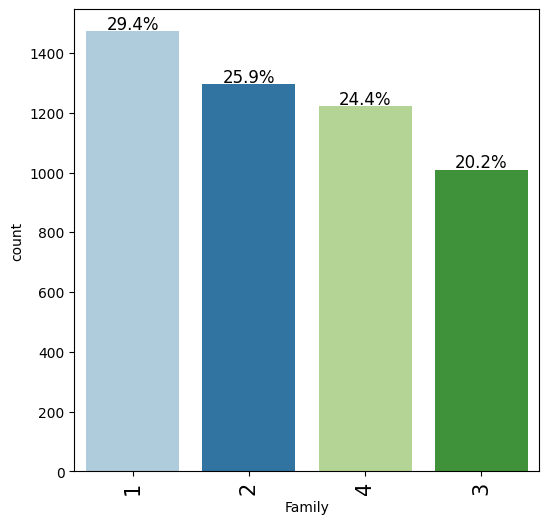

In [ ]:
# Creating labeled barplot for Family
labeled_barplot(data, 'Family', perc=True)

**Observations**


*   Most customers are individuals (slightly under 30%) and the least are those with a family size of 3 (around 20%)
*   Number of customers with families of sizes 2 or 4 account for around 25% each of the total customers.



#### Education

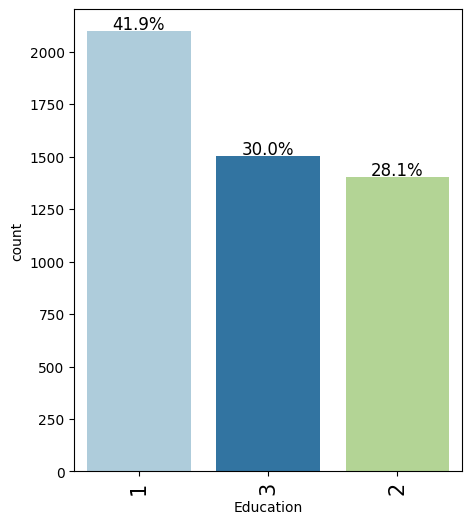

In [ ]:
# Creating labeled barplot for Education
labeled_barplot(data, 'Education', perc=True)

**Observations**


*   Undergrads are the largest group of customers (around 42%)
*   Graduates and those with Advanced/Professional education have around the same distribution with the latter group being slightly higher (30% to 28%)



#### Securities Account

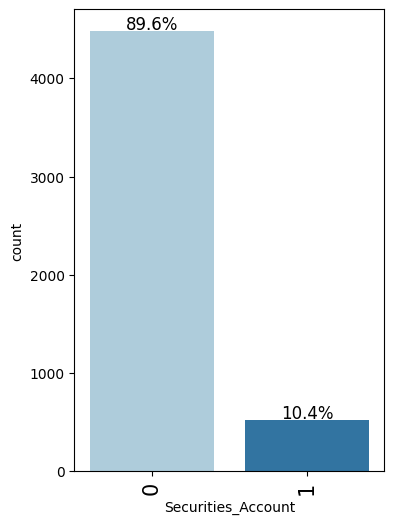

In [ ]:
# Creating labeled barplot for Securities Account
labeled_barplot(data, 'Securities_Account', perc=True)

**Observations**


*   Around 10.4% of customers have a Securities Account



#### Certificate of Deposit Account

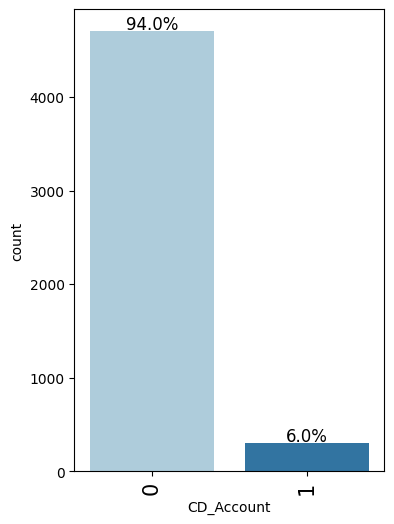

In [ ]:
# Creating labeled barplot for Certificate of Deposit Account
labeled_barplot(data, 'CD_Account', perc=True)

**Observations**


*   Around 6% of customers have a Certificate of Deposit account



#### Online

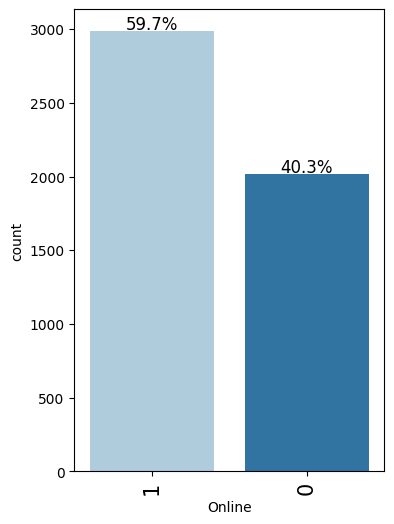

In [ ]:
# Creating labeled barplot for Online
labeled_barplot(data, 'Online', perc=True)

**Observations**


*   Approximately 60% of customers use online banking



#### Credit Card

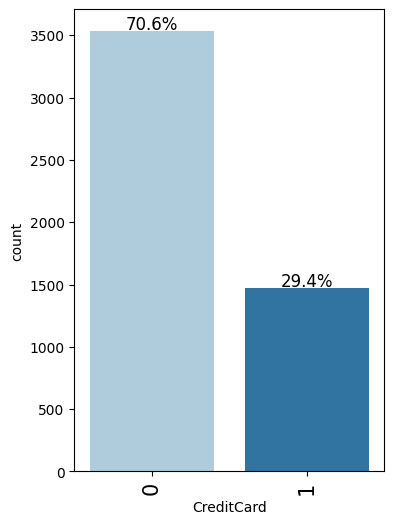

In [ ]:
# Creating labeled barplot for Credit Card
labeled_barplot(data, 'CreditCard', perc=True)

In [ ]:
data[data['CreditCard'] == 1].shape

(1470, 13)

**Observations**


*   Approximately 30% of customers have credit cards from other banks



#### Zip Code

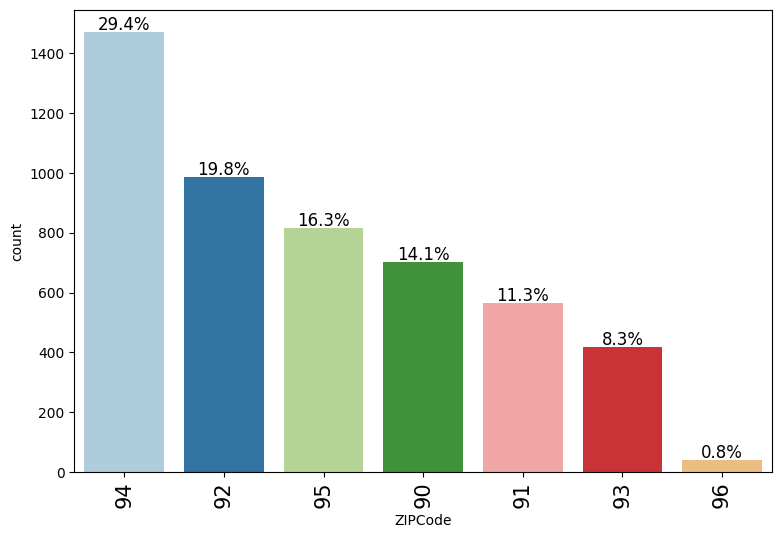

In [ ]:
# Creating labeled barplot for Zip Code
labeled_barplot(data, 'ZIPCode', perc=True)

**Observations**


*   List item
*   List item



### Bivariate Analysis

#### Correlation

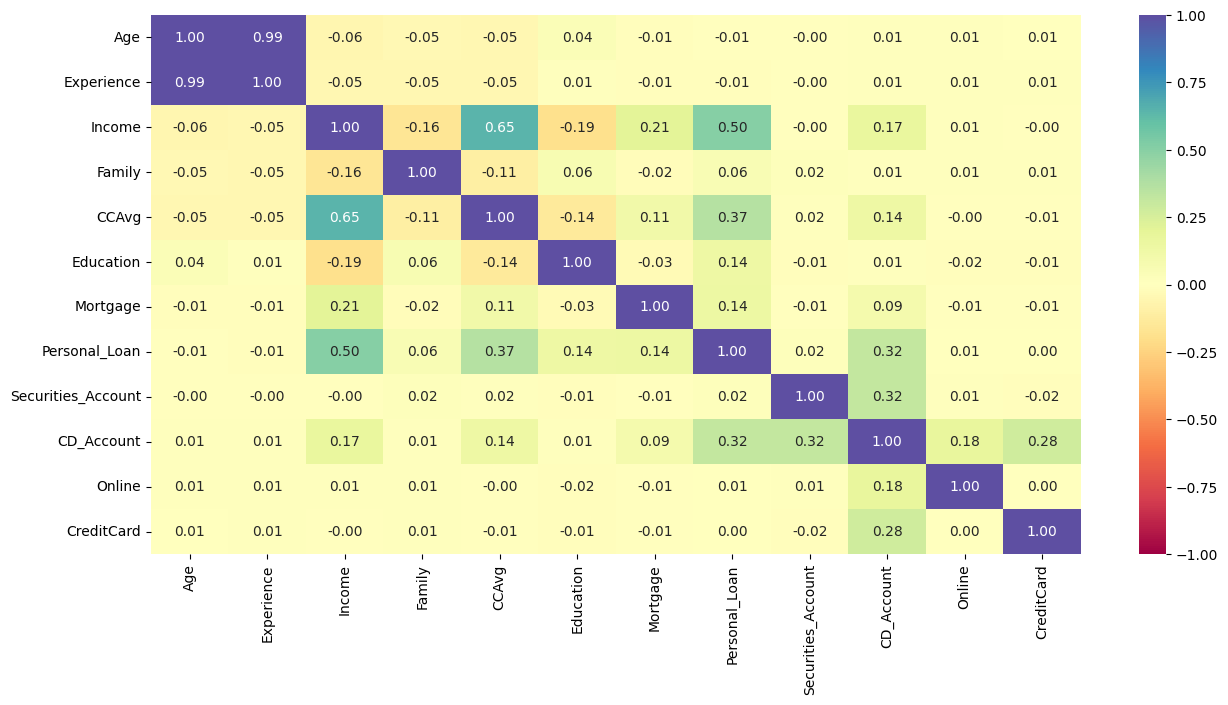

In [ ]:
# Check correlation between columns in the dataset
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations**


*   One between Age and Experience can be dropped from the data model being built as they have  a 99% correlation between them
*   List item



#### Personal Loan purchase based on ZIP Code

Personal_Loan     0    1   All
ZIPCode                       
All            4520  480  5000
94             1334  138  1472
92              894   94   988
95              735   80   815
90              636   67   703
91              510   55   565
93              374   43   417
96               37    3    40
------------------------------------------------------------------------------------------------------------------------


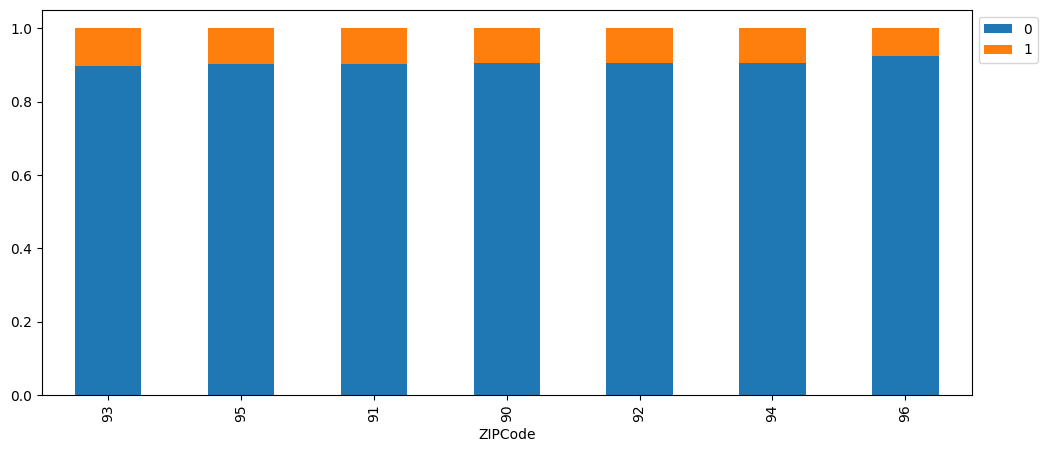

In [ ]:
stacked_barplot(data, 'ZIPCode', 'Personal_Loan')

#### Personal Loan purchase based on Family

Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


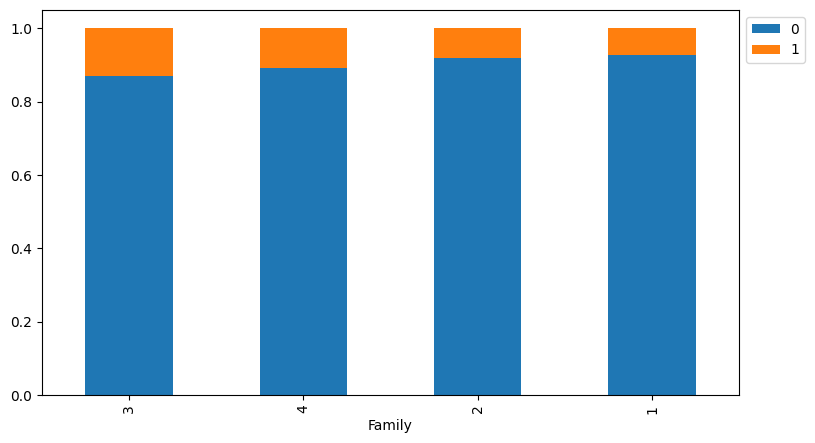

In [ ]:
stacked_barplot(data, 'Family', 'Personal_Loan')

#### Personal Loan purchase based on Education

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
3              1296  205  1501
2              1221  182  1403
1              2003   93  2096
------------------------------------------------------------------------------------------------------------------------


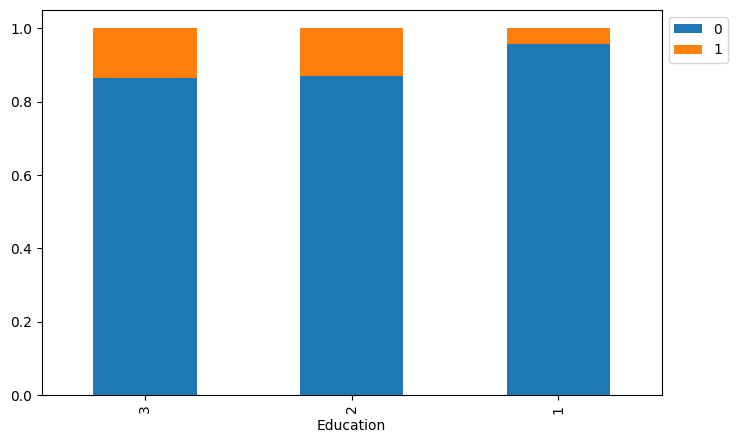

In [ ]:
stacked_barplot(data, 'Education', 'Personal_Loan')

#### Personal Loan purchase based on Securities Account

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


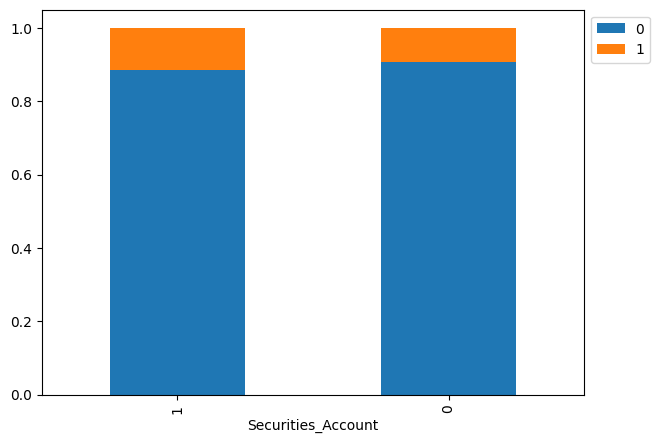

In [ ]:
stacked_barplot(data, 'Securities_Account', 'Personal_Loan')

#### Personal Loan purchase based on Certificate of Deposit Account

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


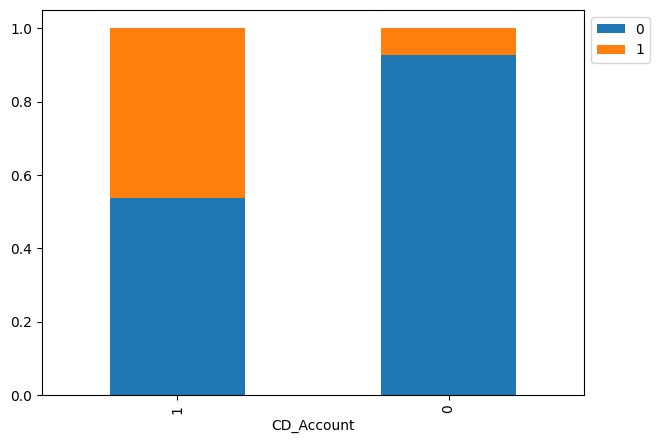

In [ ]:
stacked_barplot(data, 'CD_Account', 'Personal_Loan')

#### Personal Loan purchase based on Online banking

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


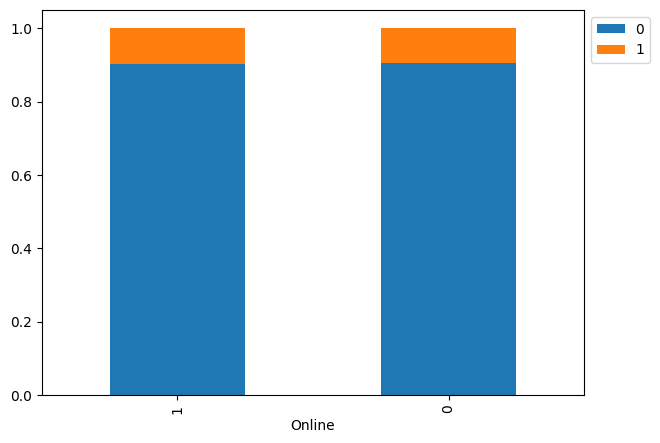

In [ ]:
stacked_barplot(data, 'Online', 'Personal_Loan')

#### Personal Loan purchase based on Age

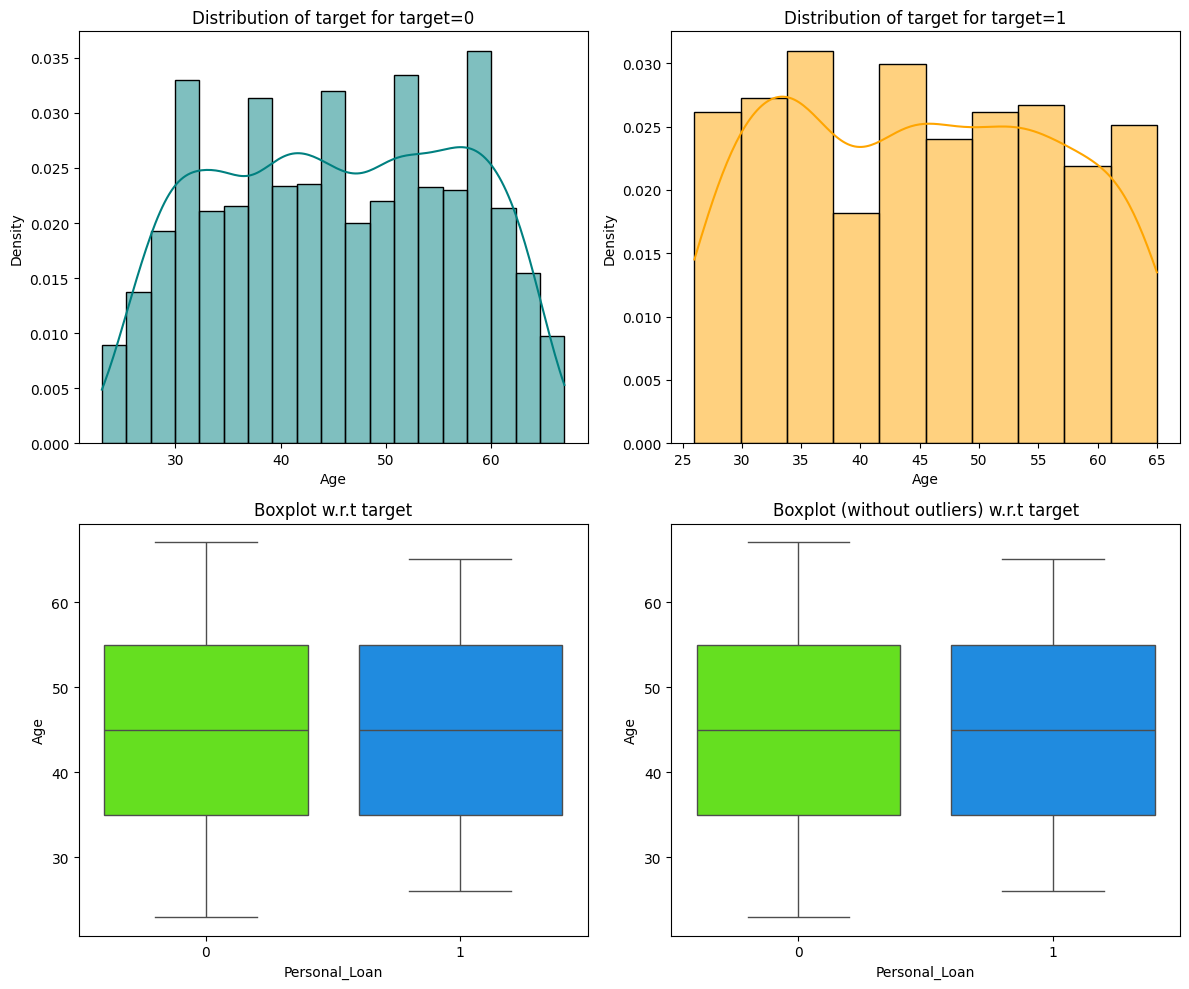

In [ ]:
distribution_plot_wrt_target(data, 'Age', 'Personal_Loan')

#### Personal Loan purchase based on Experience

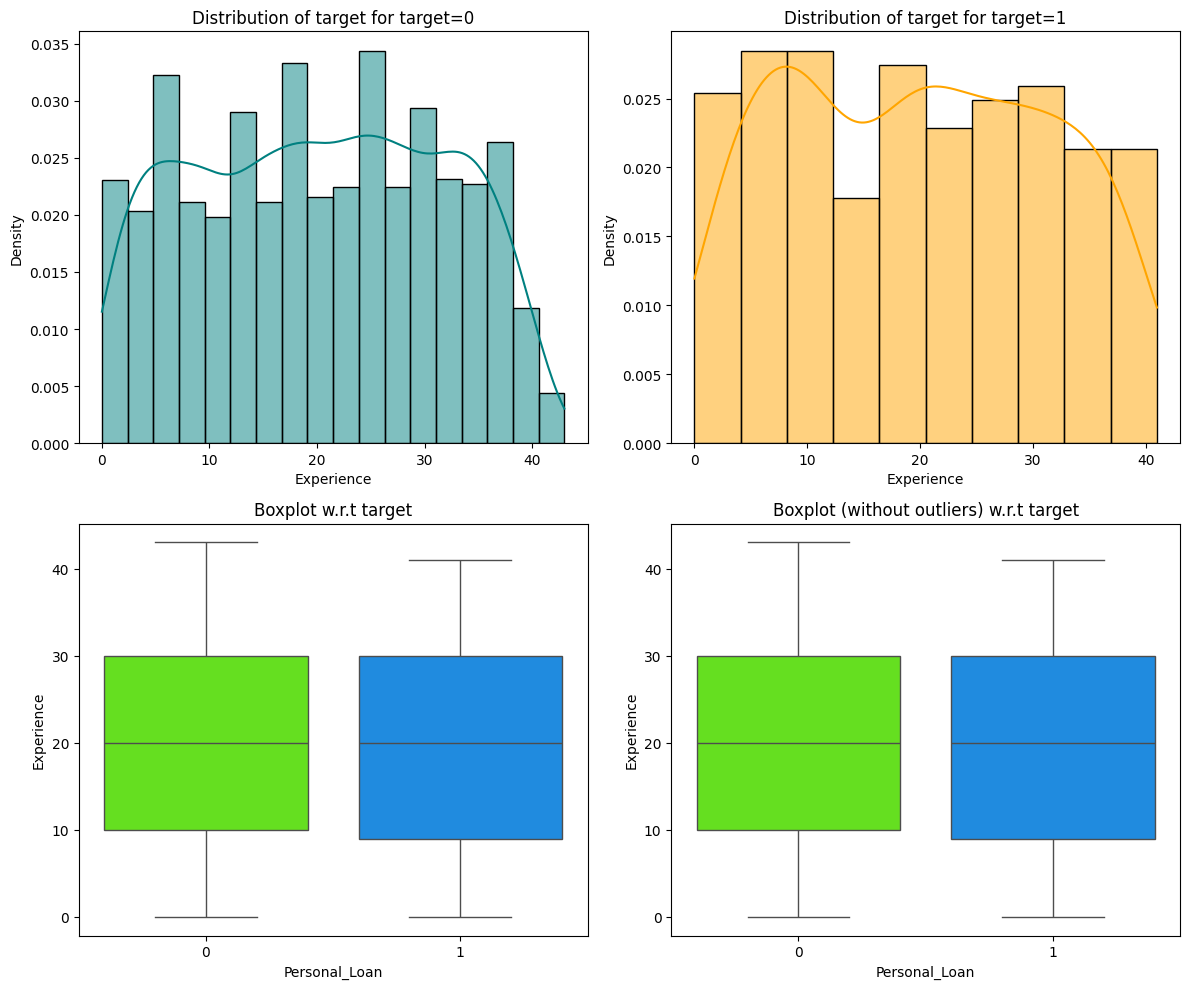

In [ ]:
distribution_plot_wrt_target(data, 'Experience', 'Personal_Loan')

#### Personal Loan purchase based on Income

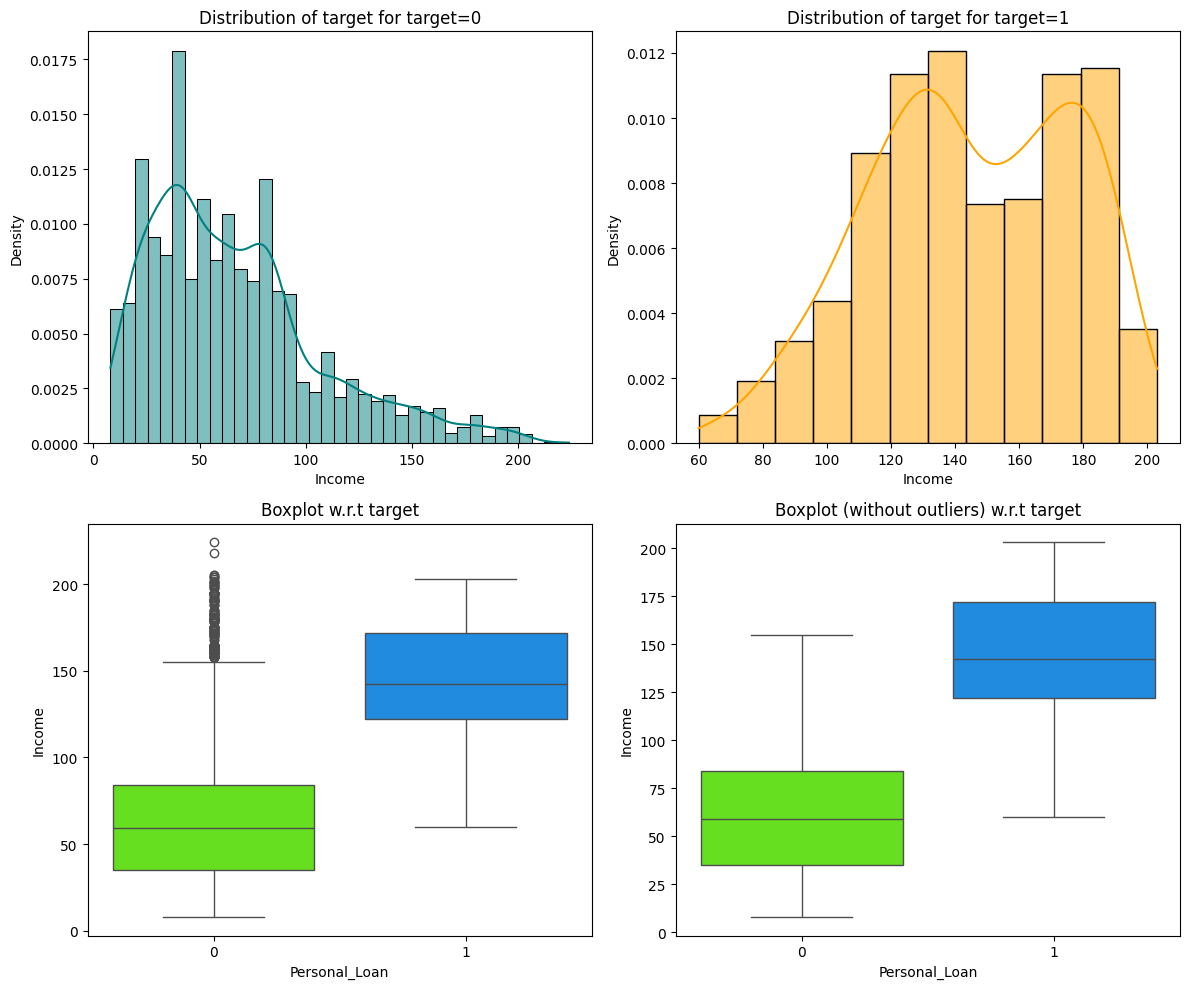

In [ ]:
distribution_plot_wrt_target(data, 'Income', 'Personal_Loan')

#### Personal Loan purchase based on Average monthly spending on credit card

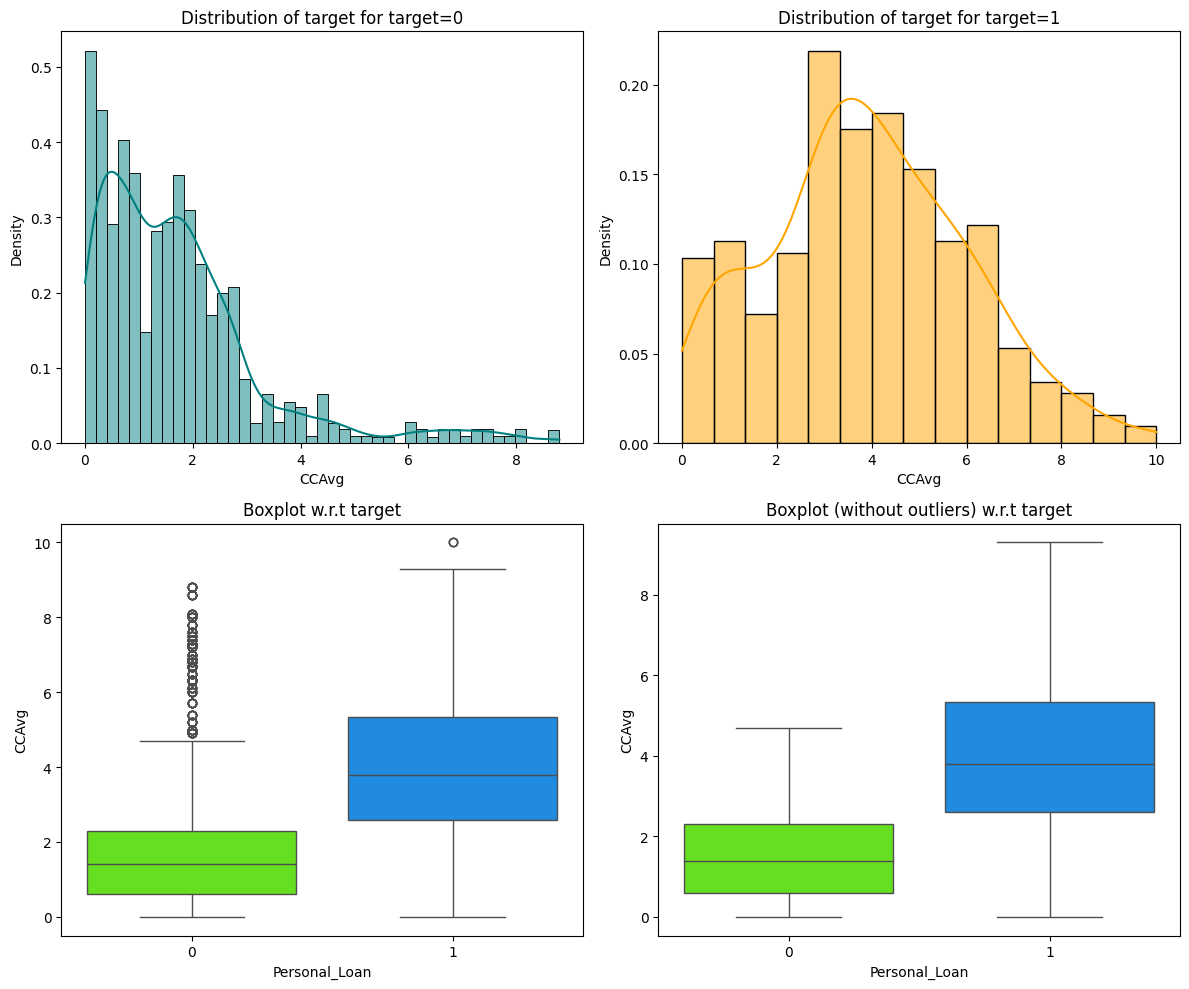

In [ ]:
distribution_plot_wrt_target(data, 'CCAvg', 'Personal_Loan')

#### Personal Loan purchase based on House Mortgage value

KeyboardInterrupt: 

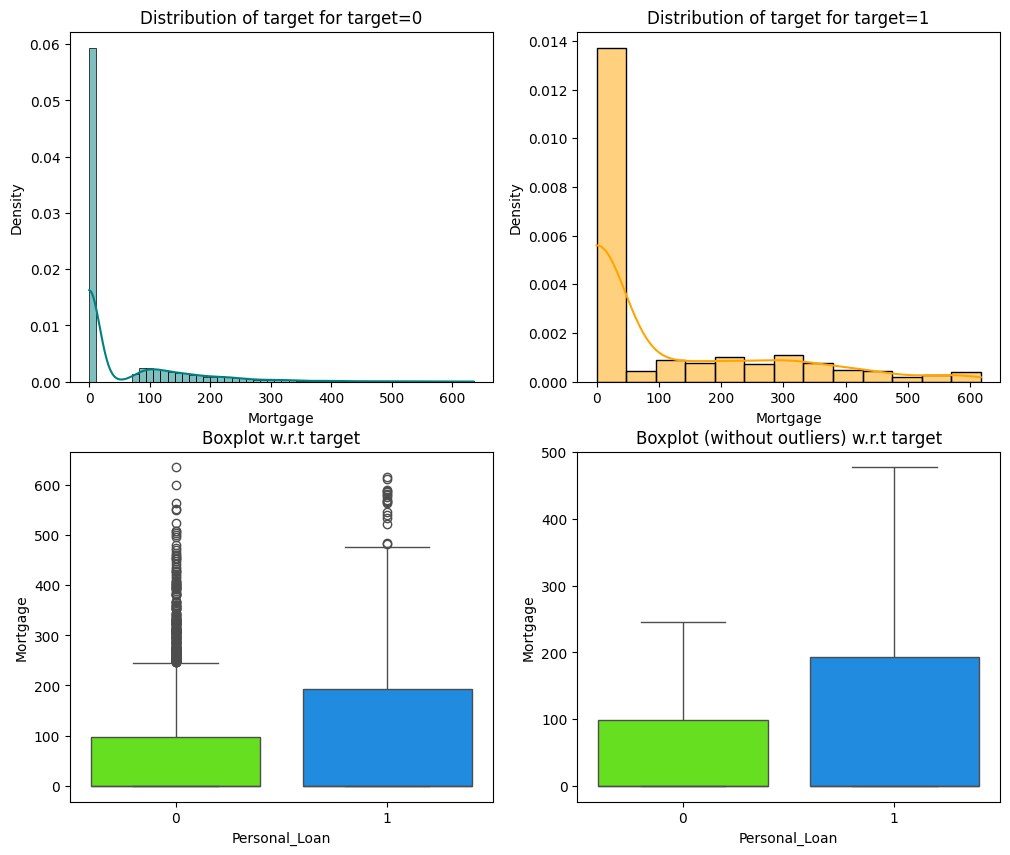

In [ ]:
distribution_plot_wrt_target(data, 'Mortgage', 'Personal_Loan')

**Questions and Answers (based on observations from EDA)**:



---


1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

> 3462 customers do not have any mortgage (value is zero). This leaves the data heavily skewed towards the right with a significant number of outliers.


---
2. How many customers have credit cards?


> It is difficult to state how many customers have credit cards as the provided dataset only indicates if a customer has credit cards from another bank and not if they have a credit card with AllLife Bank. 1470 customers have credit cards from other banks.


---



3. What are the attributes that have a strong correlation with the target attribute (personal loan)?


> None of the attributes have a strong correlation with the target attribute (Personal Loan). The attribute with the highest correlation (0.5) with Personal Loan is Income.  


---



4. How does a customer's interest in purchasing a loan vary with their age?

> Age has a very small correlation (-0.01) with purchasing a loan.


---



5. How does a customer's interest in purchasing a loan vary with their education?

> Graduates or those with Advanced/Professional education are more likely to purchase a loan compared with Undergraduates.


---





## Data Preprocessing Continued                                                                                                                                                                      

### Outlier Detection

In [ ]:
# Calculating 25th (Q1) and 75th (Q3) Percentiles
Q1 = data.select_dtypes(include=["float64", "int64"]).quantile(0.25)
Q3 = data.select_dtypes(include=["float64", "int64"]).quantile(0.75)

# Calculating Inter Quartile Range
IQR = Q3 - Q1

# Finding lower and upper bounds for all attribtues
lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

In [ ]:
(
    (data.select_dtypes(include=["float64", "int64"]) < lower)
    | (data.select_dtypes(include=["float64", "int64"]) > upper)
).sum() / len(data) * 100

,0
Age,0.00
Experience,0.00
Income,1.92
Family,0.00
CCAvg,6.48
Education,0.00
Mortgage,5.82
Personal_Loan,9.60
Securities_Account,10.44
CD_Account,6.04


### Modeling Data Preparation

#### Dropping Experience Attributed

Dropping the Experience as previously stated due to the string correlation with Age. Only one of the two columns is needed in the dataset.

In [ ]:
from sklearn.model_selection import train_test_split

# dropping Experience as it is perfectly correlated with Age
X = data.drop(["Personal_Loan", "Experience"], axis=1)
Y = data["Personal_Loan"]

X = pd.get_dummies(X, columns=["ZIPCode", "Education"], drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 17)
Shape of test set :  (1500, 17)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

*


### Reusable functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
# Method to visualize the decision tree
def visualize_decision_tree(model, feature_names):

  plt.figure(figsize=(20, 10))
  out = tree.plot_tree(
      model,
      feature_names=feature_names,
      filled=True,
      fontsize=9,
      node_ids=False,
      class_names=None,
  )
  # below code will add arrows to the decision tree split if they are missing
  for o in out:
      arrow = o.arrow_patch
      if arrow is not None:
          arrow.set_edgecolor("black")
          arrow.set_linewidth(1)
  plt.show()

### Model Building

#### Decision Tree (Default)

In [ ]:
model_dtree_default = DecisionTreeClassifier(random_state=1)
model_dtree_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

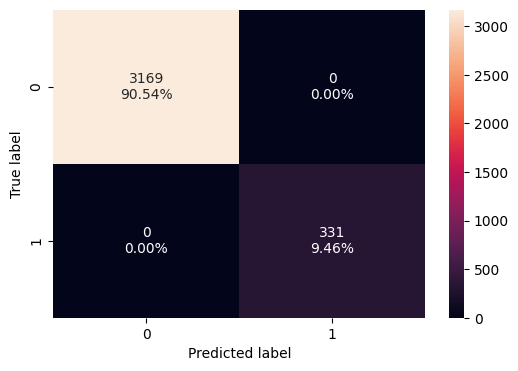

In [ ]:
confusion_matrix_sklearn(model_dtree_default, X_train, y_train)

In [ ]:
dtree_default_perf_train = model_performance_classification_sklearn(
    model_dtree_default, X_train, y_train
)
dtree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


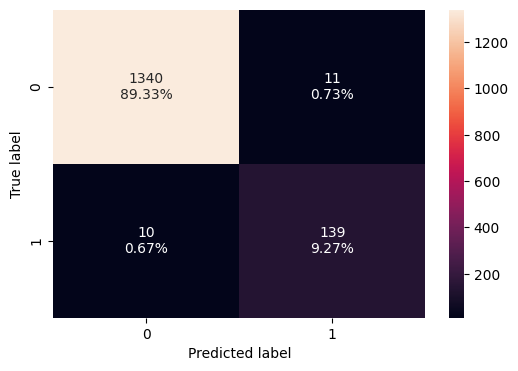

In [ ]:
confusion_matrix_sklearn(model_dtree_default, X_test, y_test)

In [ ]:
dtree_default_perf_test = model_performance_classification_sklearn(
    model_dtree_default, X_test, y_test
)
dtree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.986,0.932886,0.926667,0.929766


#### Decision Tree (with class weights)

In [ ]:
dtree_class_weights = DecisionTreeClassifier(class_weight="balanced", random_state=1)
dtree_class_weights.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

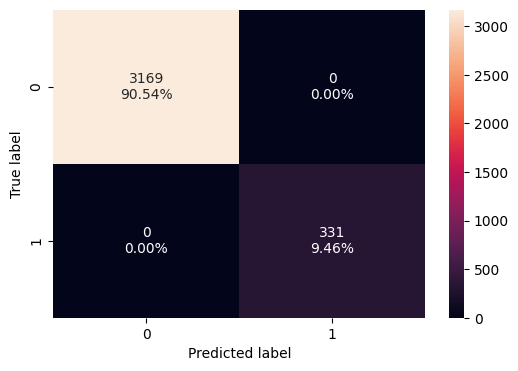

In [ ]:
confusion_matrix_sklearn(dtree_class_weights, X_train, y_train)

In [ ]:
dtree_class_weights_perf_train = model_performance_classification_sklearn(
    dtree_class_weights, X_train, y_train
)
dtree_class_weights_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


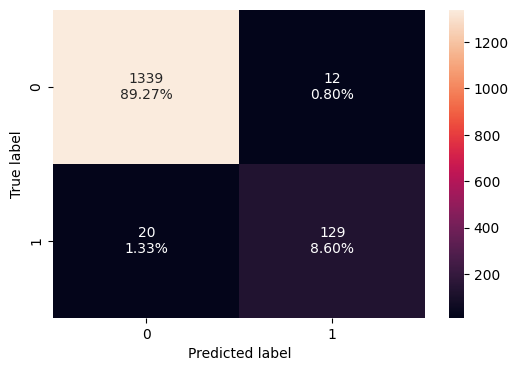

In [ ]:
confusion_matrix_sklearn(dtree_class_weights, X_test, y_test)

In [ ]:
dtree_class_weights_perf_test = model_performance_classification_sklearn(
    dtree_class_weights, X_test, y_test
)
dtree_class_weights_perf_test

,Accuracy,Recall,Precision,F1
0,0.978667,0.865772,0.914894,0.889655


## Model Performance Improvement

#### Reusable Functions

In [ ]:
# Function to plot importance of features in the tree building
def plot_model_feature_importance(model, feature_names):

  importances = model.feature_importances_
  indices = np.argsort(importances)

  plt.figure(figsize=(8, 8))
  plt.title("Feature Importances")
  plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
  plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
  plt.xlabel("Relative Importance")
  plt.show()

### Pre-pruning

#### Decision Tree (Pre-pruning)

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [ ]:
# Creating an instance of the best model
dtree_prepruned = best_estimator

# Fitting best model to training data
dtree_prepruned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10,
                       random_state=42)

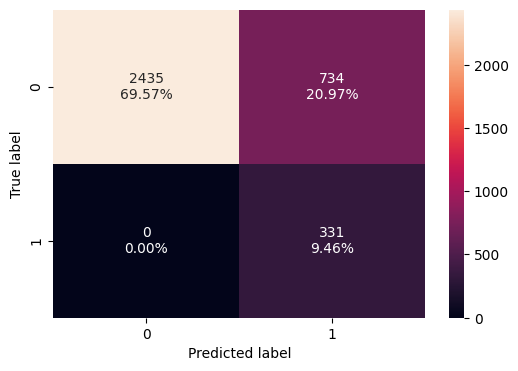

In [ ]:
confusion_matrix_sklearn(dtree_prepruned, X_train, y_train)

In [ ]:
dtree_prepruned_perf_train = model_performance_classification_sklearn(
    dtree_prepruned, X_train, y_train
)
dtree_prepruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.790286,1.0,0.310798,0.474212


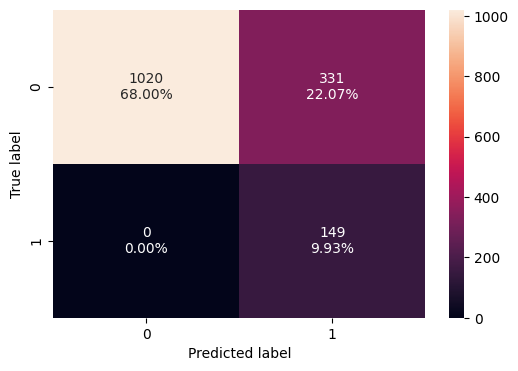

In [ ]:
confusion_matrix_sklearn(dtree_prepruned, X_test, y_test)

In [ ]:
dtree_prepruned_perf_test = model_performance_classification_sklearn(
    dtree_prepruned, X_test, y_test
)
dtree_prepruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.779333,1.0,0.310417,0.473768


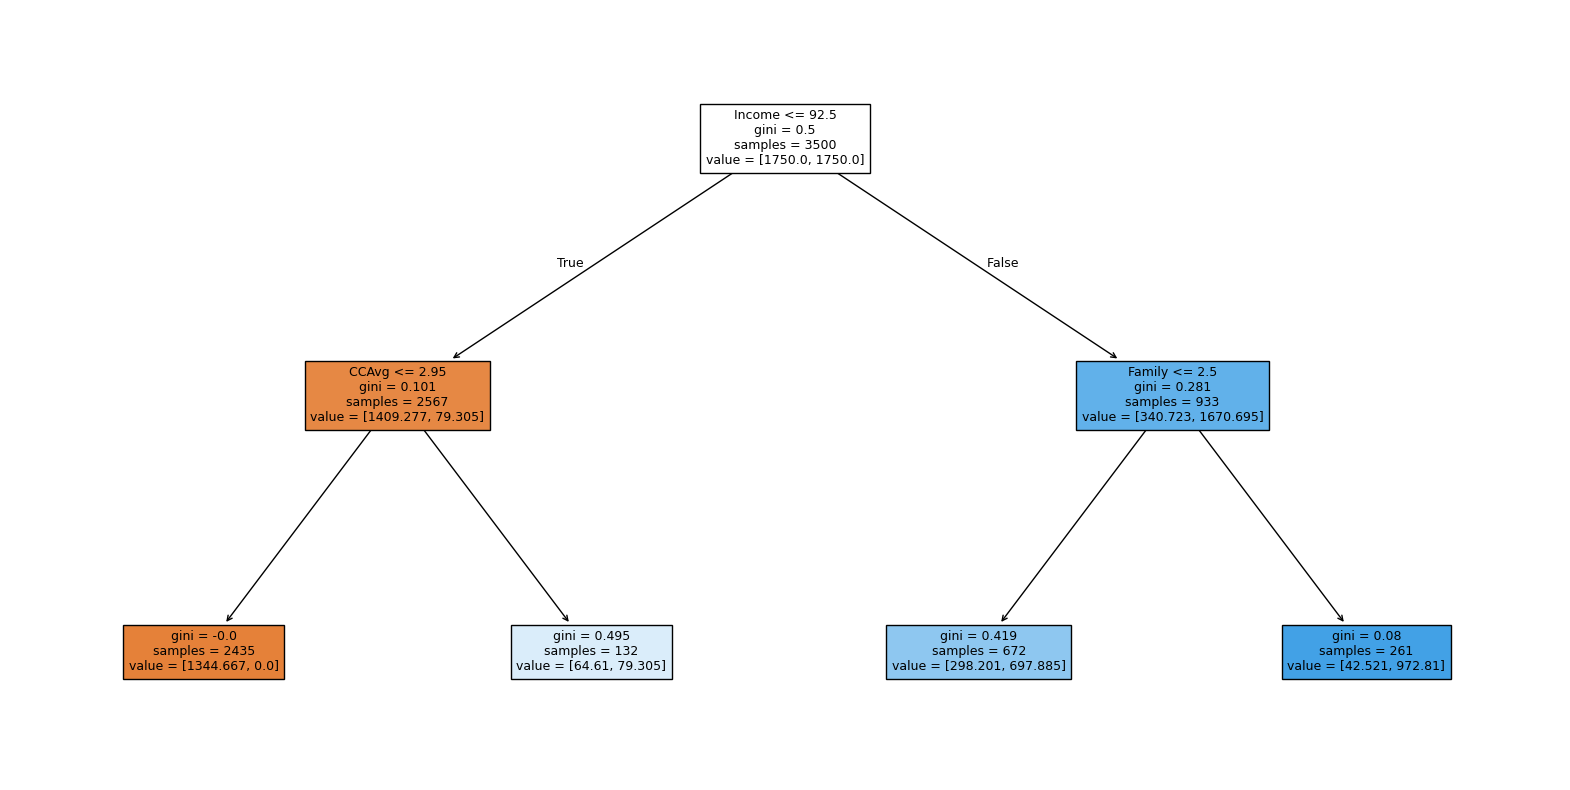

In [ ]:
feature_names = list(X_train.columns)
importances = dtree_prepruned.feature_importances_
indices = np.argsort(importances)
visualize_decision_tree(dtree_prepruned, feature_names)

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(dtree_prepruned, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [64.61, 79.31] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- weights: [298.20, 697.89] class: 1
|   |--- Family >  2.50
|   |   |--- weights: [42.52, 972.81] class: 1



Based on the above a customer is likely to avail a personal loan if:

*   Income is less than or equal to 92.5K and Average monthly spend on credit cards is greater than 2.95K
*   Income is greater than 92.5K



In [ ]:
importances = dtree_prepruned.feature_importances_
importances

array([0.        , 0.87652937, 0.05653065, 0.06693998, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        ])

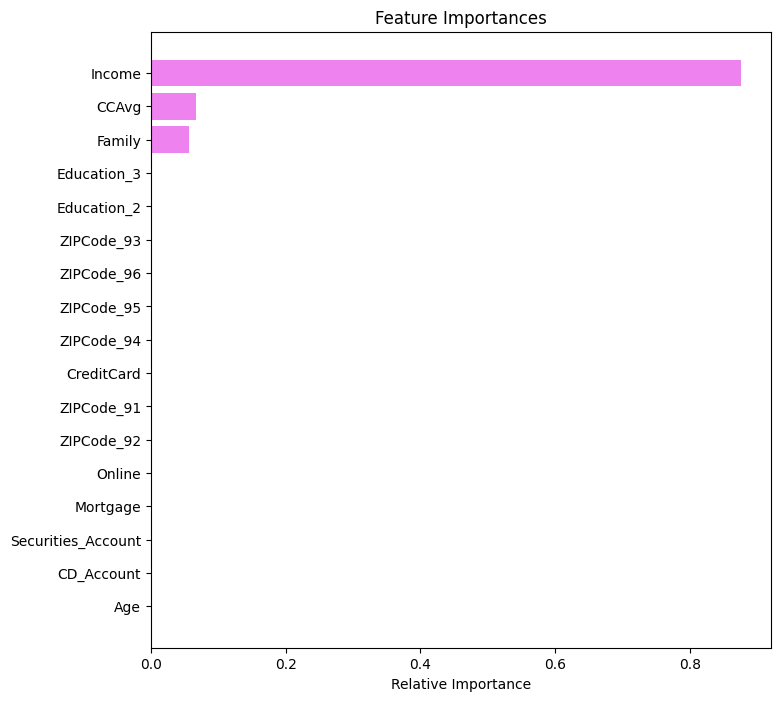

In [ ]:
plot_model_feature_importance(dtree_prepruned, feature_names)

### Post-pruning

#### Decision Tree (Post-pruned)

In [ ]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-7.759588e-16
1,3.853725e-19,-7.755734e-16
2,4.729571e-19,-7.751004e-16
3,5.255079e-19,-7.745749e-16
4,5.255079e-19,-7.740494e-16
5,7.707449e-19,-7.732787e-16
6,1.051016e-18,-7.722277e-16
7,1.576524e-18,-7.706511e-16
8,1.257806e-17,-7.580731e-16
9,1.524700e-04,3.049400e-04


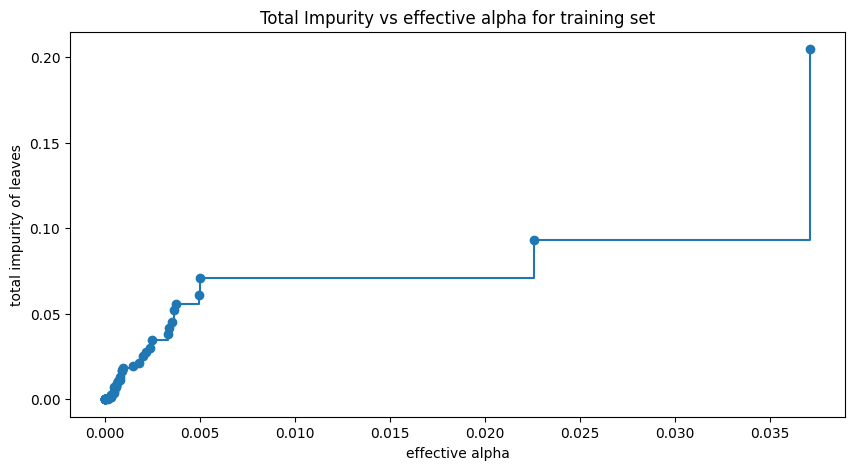

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [ ]:
# Train Decision Tree using the effective alphas

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.2953792759992314


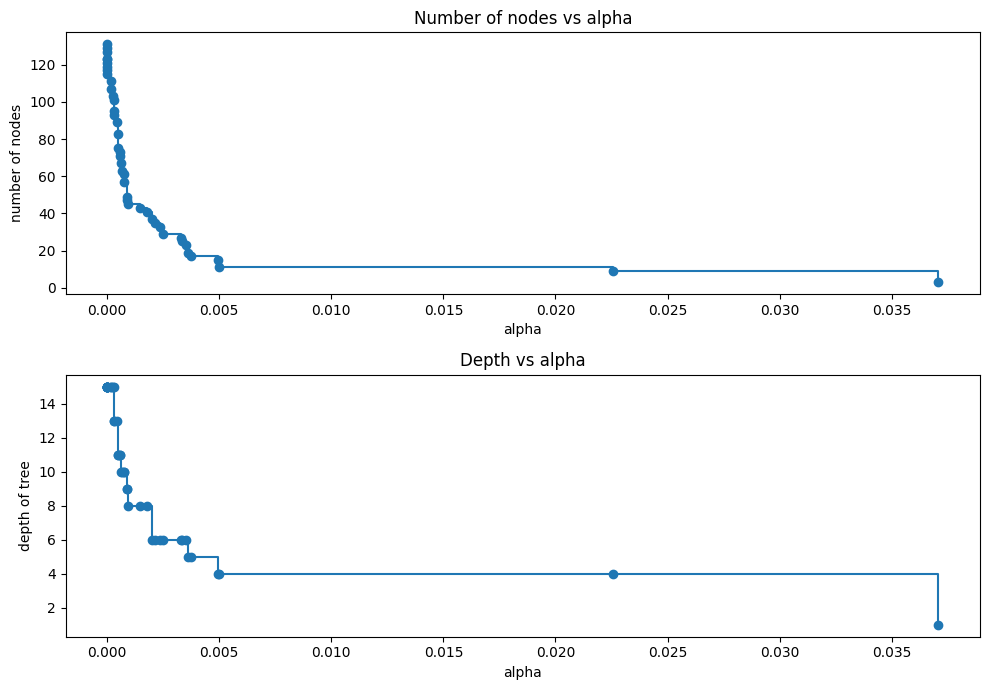

In [ ]:
# Remove the last element in clfs and ccp_alphas because it is the trivial tree with only one node
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Show effect on  number of nodes and tree depth as alpha increases
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

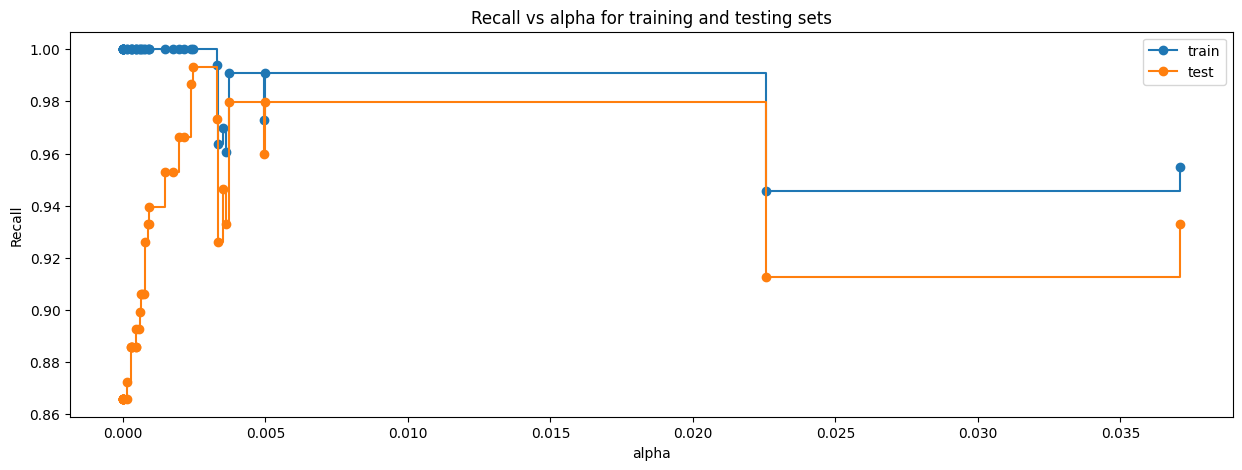

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0024726598786422157),
                       class_weight='balanced', random_state=1)


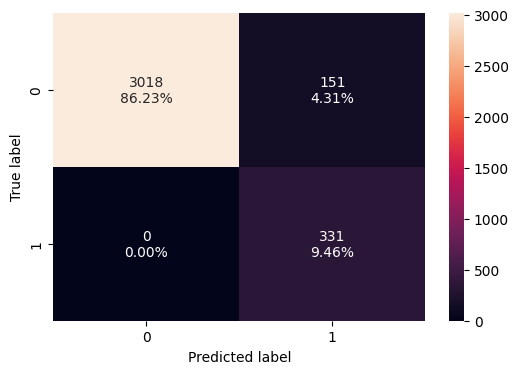

In [ ]:
dtree_post_pruned = best_model
confusion_matrix_sklearn(dtree_post_pruned, X_train, y_train)

In [ ]:
dtree_post_pruned_perf_train = model_performance_classification_sklearn(
    dtree_post_pruned, X_train, y_train
)
dtree_post_pruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.956857,1.0,0.686722,0.814268


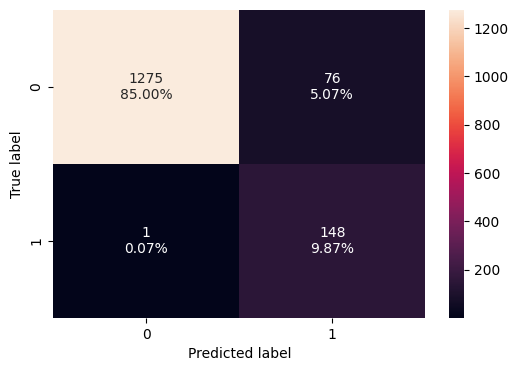

In [ ]:
confusion_matrix_sklearn(dtree_post_pruned, X_test, y_test)

In [ ]:
dtree_post_pruned_perf_test = model_performance_classification_sklearn(
    dtree_post_pruned, X_test, y_test
)
dtree_post_pruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.948667,0.993289,0.660714,0.793566


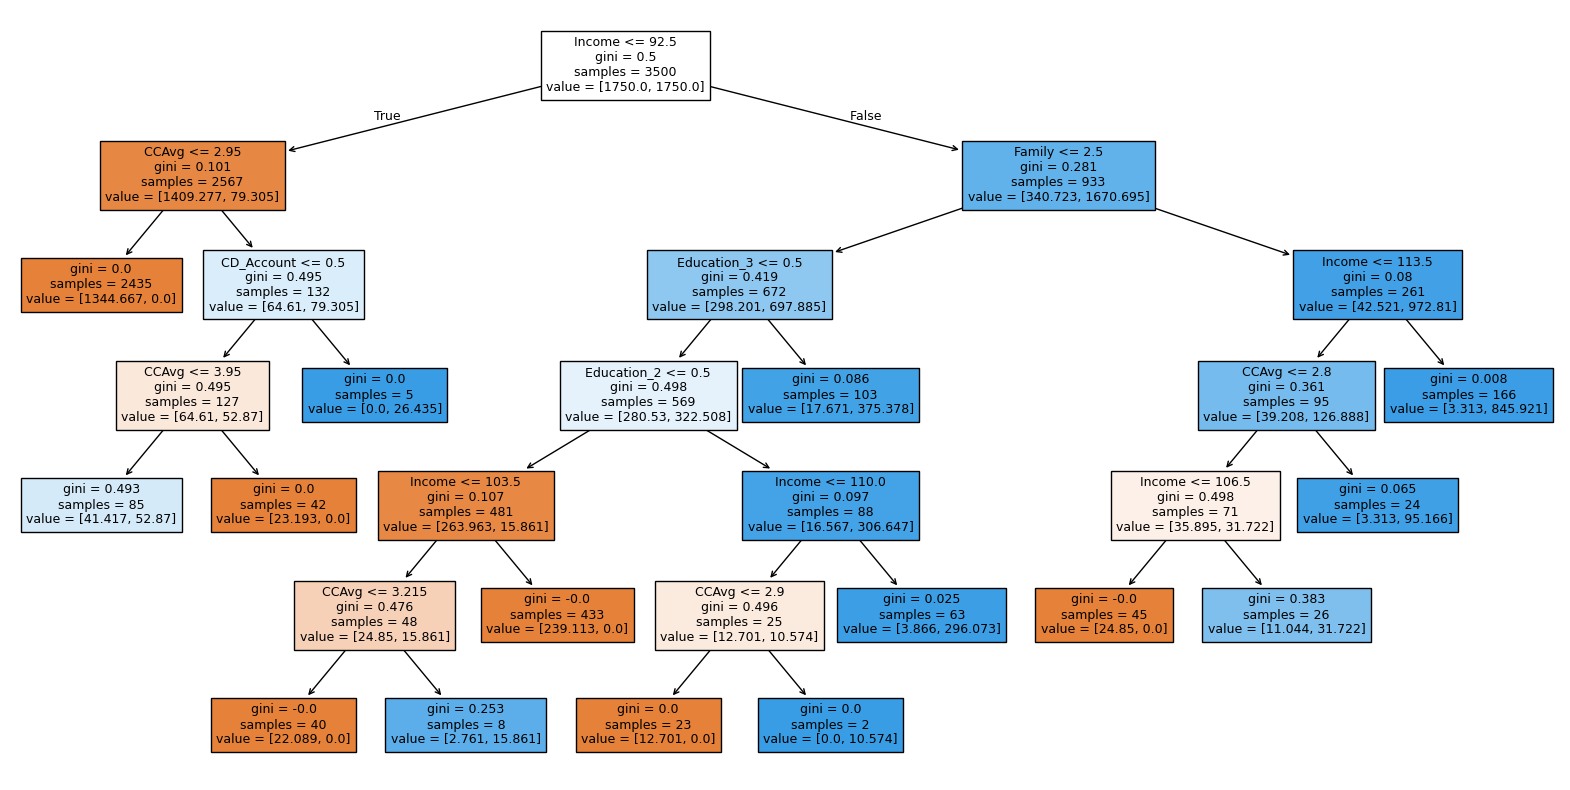

In [ ]:
visualize_decision_tree(dtree_post_pruned, feature_names)

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(dtree_post_pruned, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [41.42, 52.87] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [23.19, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.00, 26.44] class: 1
|--- Income >  92.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- Income <= 103.50
|   |   |   |   |   |--- CCAvg <= 3.21
|   |   |   |   |   |   |--- weights: [22.09, 0.00] class: 0
|   |   |   |   |   |--- CCAvg >  3.21
|   |   |   |   |   |   |--- weights: [2.76, 15.86] class: 1
|   |   |   |   |--- Income >  103.50
|   |   |   |   |   |--- weights: [239.11, 0.00] class: 0
|   |   |   |--- Education_2 >  0.50
|   |   |   |   |--- Income <= 110.00
|   |   |   |   |   |--- CCAvg <= 2.90
|   |   |   |   |   |   |--- weights: [12

In [ ]:
importances = dtree_post_pruned.feature_importances_
indices = np.argsort(importances)

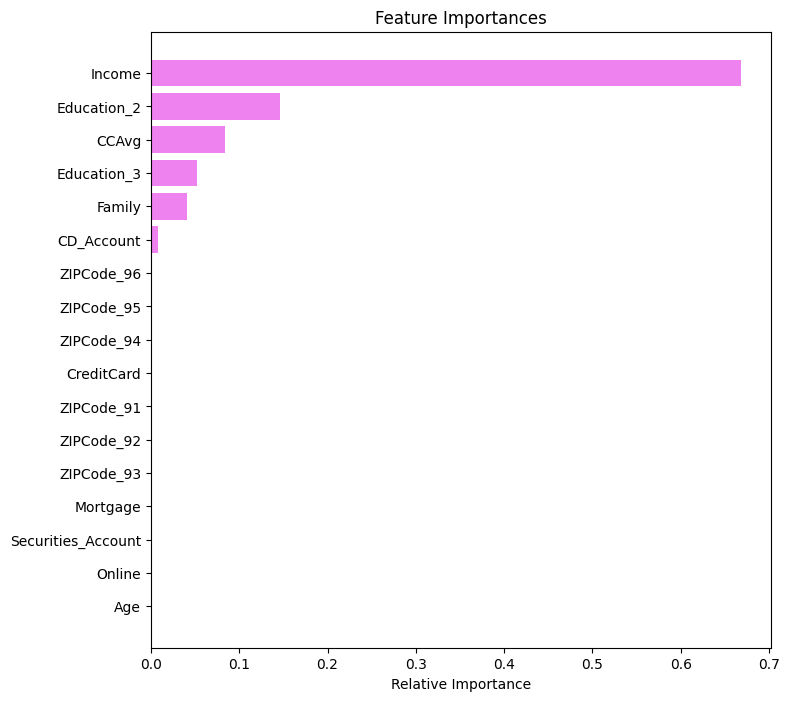

In [ ]:
plot_model_feature_importance(dtree_post_pruned, feature_names)

## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_default_perf_train.T,
        dtree_class_weights_perf_train.T,
        dtree_prepruned_perf_train.T,
        dtree_post_pruned_perf_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.790286,0.956857
Recall,1.0,1.0,1.000000,1.000000
Precision,1.0,1.0,0.310798,0.686722
F1,1.0,1.0,0.474212,0.814268


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree_default_perf_test.T,
        dtree_class_weights_perf_test.T,
        dtree_prepruned_perf_test.T,
        dtree_post_pruned_perf_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.986000,0.978667,0.779333,0.948667
Recall,0.932886,0.865772,1.000000,0.993289
Precision,0.926667,0.914894,0.310417,0.660714
F1,0.929766,0.889655,0.473768,0.793566




*   The post-pruned decision tree model offers the best combination of Precision and Recall and is recommended to be used in this business use case. While it's Precision may not be as high as the default models it is significantly higher than the pre-pruned model.
*   While the post-pruned model's Precision may not be as high as the default models it is significantly higher than the pre-pruned model.



## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

1. High-Value, High-Confidence Target Segments (Primary Focus)
A. High Income Customers (> 92.5)

This is the strongest driver of positive outcomes.

Actionable Insight

Prioritize customers with Income > 92.5, especially those with higher education, larger families, or higher credit card spending.

Key Sub-segments

Income > 113.5 → Extremely strong Class 1 signal
→ Auto-qualify for premium offers

Family > 2.5 AND CCAvg > 2.8 → Very high conversion
→ Bundle family-oriented financial products

Education level = Graduate (Education_3) regardless of family size
→ Target with sophisticated, value-based messaging

Business Action

Use pre-approved offers and minimal friction journeys

Assign relationship managers or priority digital nudges

2. Credit Card Spend (CCAvg) Is a Strong Intent Signal
Across almost all branches:

CCAvg > ~2.8–3.2 sharply increases likelihood of Class 1

Low spenders almost always fall into Class 0

Actionable Insight

Credit card usage is a proxy for engagement and liquidity

Business Action

Trigger offers when CCAvg crosses 3

Use spend-based campaigns (e.g., “based on your recent spending…”)

Exclude CCAvg < 2.8 customers from aggressive marketing

3. Lower Income Customers (≤ 92.5): Be Selective
A. Low Income + Low CCAvg

Income ≤ 92.5 AND CCAvg ≤ 2.95 → Strong Class 0

Actionable Insight

These customers have very low conversion probability

Business Action

Avoid costly outbound campaigns

Offer educational or low-risk products instead

B. Low Income but High Engagement (Hidden Opportunity)

Income ≤ 92.5 AND CCAvg > 2.95

CD Account holders → Strong Class 1

CCAvg between 2.95 and 3.95 → Moderate Class 1

Actionable Insight

Engagement can compensate for lower income

Business Action

Cross-sell to existing CD account holders

Position offers as relationship upgrades, not income-based

4. Education Is a Major Differentiator
Education Level 3 (Advanced Degree)

Strong Class 1 regardless of family size

Education Level 2 (Undergraduate)

Converts well only with higher income or higher CCAvg

Actionable Insight

Education increases financial confidence and decision readiness

Business Action

Tailor messaging:

Education_3 → ROI, optimization, long-term value

Education_2 → affordability + upside

Use education as a segmentation filter in campaigns

5. Family Size Amplifies Value at Higher Income

Family > 2.5 AND Income > 106.5 → Strong Class 1

Small families need higher spend or education to convert

Actionable Insight

Larger families correlate with greater financial needs

Business Action

Promote:

bundled products

insurance + credit + savings combos

Use life-stage messaging (kids, education, planning)

6. Who to Deprioritize (Cost Control)

Avoid heavy investment in:

Income ≤ 92.5 AND CCAvg ≤ 2.95

Income > 103.5 but low CCAvg

Small families, low education, low spend

Business Action

Suppress these segments from paid campaigns

Keep only low-touch digital communication

7. Operational Recommendations
Marketing

Build rules-based targeting using:

Income > 92.5

CCAvg > 3

Education_3 OR Family > 2.5

Use event-based triggers on spending changes

Sales / Product

Auto-approve high-confidence segments

Introduce tiered offers based on CCAvg bands

Analytics

Track CCAvg uplift as an early conversion signal

Use education + income as leading predictors, not demographics alone

In [ ]:
!jupyter nbconvert "/content/drive/MyDrive/Learning/UT Austin/02 - Machine Learning/Project/ThomasJoseph_AIML_ML_Project_Full_Code_Notebook.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Learning/UT Austin/02 - Machine Learning/Project/ThomasJoseph_AIML_ML_Project_Full_Code_Notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 39 image(s).
[NbConvertApp] Writing 2416431 bytes to /content/drive/MyDrive/Learning/UT Austin/02 - Machine Learning/Project/ThomasJoseph_AIML_ML_Project_Full_Code_Notebook.html
